In [1]:
from langgraph.graph import StateGraph, START, END
# from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

model = ChatGroq(model="openai/gpt-oss-120b")

In [3]:
model.invoke("What is python").content

'**Python** is a high‑level, interpreted programming language that emphasizes readability, simplicity, and flexibility. It was created by **Guido van Rossum** and first released in 1991. Here’s a quick overview of what makes Python special:\n\n| Aspect | Details |\n|--------|---------|\n| **Design Philosophy** | *“There should be one—and preferably only one—obvious way to do it.”* Python’s syntax is clean and expressive, making code easy to read and maintain. |\n| **Interpreted** | You run Python code directly with the interpreter (`python script.py`) instead of compiling it first. This speeds up development and testing. |\n| **Dynamic Typing** | Variables don’t need explicit type declarations; the interpreter determines types at runtime. |\n| **Rich Standard Library** | A “batteries‑included” collection of modules for tasks like file I/O, networking, web services, data serialization, regular expressions, and more. |\n| **Cross‑Platform** | Works on Windows, macOS, Linux, and many embe

In [4]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [5]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [7]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()


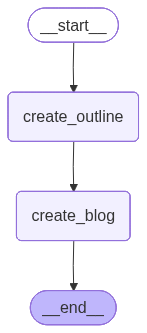

In [8]:
graph.compile()

In [9]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': '**Blog Title:** *The Rise of AI in India: Opportunities, Challenges, and the Road Ahead*  \n\n**Target Audience:** Tech enthusiasts, policymakers, entrepreneurs, students, investors, and anyone curious about India’s AI ecosystem.  \n\n---\n\n## 1. Introduction  \n- **Hook:** A striking statistic or anecdote (e.g., “India is projected to become the world’s third‑largest AI market by 2027, with a $35\u202fbillion industry value.”)  \n- **Why it matters:** Briefly explain AI’s transformative power globally and why India’s trajectory is especially noteworthy.  \n- **Thesis statement:** Outline the blog’s purpose – to map out the forces driving AI’s growth in India, showcase key milestones, examine sectoral impacts, and discuss the challenges and future outlook.  \n\n---\n\n## 2. Historical Context: From Early Experiments to a National Mission  \n### 2.1 Early AI research in Indian academia (1970s‑1990s)  \n- Pioneering institutes (IITs, IISc, IS

In [10]:
print(final_state['outline'])

**Blog Title:** *The Rise of AI in India: Opportunities, Challenges, and the Road Ahead*  

**Target Audience:** Tech enthusiasts, policymakers, entrepreneurs, students, investors, and anyone curious about India’s AI ecosystem.  

---

## 1. Introduction  
- **Hook:** A striking statistic or anecdote (e.g., “India is projected to become the world’s third‑largest AI market by 2027, with a $35 billion industry value.”)  
- **Why it matters:** Briefly explain AI’s transformative power globally and why India’s trajectory is especially noteworthy.  
- **Thesis statement:** Outline the blog’s purpose – to map out the forces driving AI’s growth in India, showcase key milestones, examine sectoral impacts, and discuss the challenges and future outlook.  

---

## 2. Historical Context: From Early Experiments to a National Mission  
### 2.1 Early AI research in Indian academia (1970s‑1990s)  
- Pioneering institutes (IITs, IISc, ISRO) and notable projects.  
- Limited funding & reliance on forei

In [11]:
print(final_state['content'])

# **The Rise of AI in India: Opportunities, Challenges, and the Road Ahead**

*Target Audience: Tech enthusiasts, policymakers, entrepreneurs, students, investors, and anyone curious about India’s AI ecosystem.*

---

## 1. Introduction  

**Hook:** *“India is projected to become the world’s third‑largest AI market by 2027, with a $35 billion industry value.”* – **NITI Aayog, 2023**  

Artificial Intelligence is no longer a futuristic buzz‑word; it is reshaping every industry—from banking to farming—at a speed that rivals the internet boom of the early 2000s. For a country of 1.4 billion people, a burgeoning tech talent pool, and an explosion of digital data, India’s AI trajectory is especially compelling.  

**Thesis:** This blog maps the forces propelling AI’s growth in India, highlights landmark achievements, dissects sector‑specific impacts, flags the challenges that loom, and sketches a pragmatic roadmap for the next decade.

---

## 2. Historical Context: From Early Experiments t